# Planning and preferences

In the previous notebook, we have shown that the best fitting model consists in a combination of planning and preferences. We have furher observed an interaction between the entropy of the preferences (i.e. how strong or certain the preference is in a particular state) and the weight of the planning. It would indeed seem that there is a trade off between the two, such that when participants have a strong preference towards a specific action, they tend to rely less on planning and vice versa. 

In this notebook, we will investigate the fit of the model in greater details and conduct additional exploratory analyses to support the idea that the task specific regressors capture the structure of the task leverage by the participants to facilitate their decision. 

# Preparing the data

In [1]:
import pandas as pd
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import arviz as az
import bambi as bmb
from scipy.special import logit
from scipy.stats import entropy
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

# ===================================================================
# Loading the raw data:
data = pd.read_csv("../../data/raw_data/all_participants_data.csv", on_bad_lines='skip')

# ===================================================================
# Data preprocessing:
# Remove nans:
data = data.dropna()
# Remove timeout:
data = data[data["timeout"] == 0]
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the dataframe:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
data['dv'] = dv_trials

# Compute offer specific decision value regressors:
data['dv_23'] = data['dv'].to_numpy() * (data['is_2'].to_numpy() + data['is_3'].to_numpy())
data['dv_14'] = data['dv'].to_numpy() * (data['is_1'].to_numpy() + data['is_4'].to_numpy())

# Compute categorical regressors that should be somewhat similar to our priors:
# Categorical offer regressor for high and low offer
data['is_12'] = data['is_1'].to_numpy() + data['is_2'].to_numpy()
data['is_34'] = data['is_3'].to_numpy() + data['is_4'].to_numpy()
# Continuous regressor for high and low offer:
data['high_vs_low'] = data['is_34'] - data['is_12']

# Categorical costs regressor
data['is_lc'] = (data['energy_cost'] == 1).astype(int).to_numpy()
data['is_hc'] = (data['energy_cost'] == 2).astype(int).to_numpy()
# Continuous costs regressor
data['hc_vs_lc'] = data['is_hc'] - data['is_lc']

# Categorical transition regressor
data['is_trans1'] = (data['transition'] == 0).to_numpy()
data['is_trans2'] = (data['transition'] == 1).to_numpy()
data['is_trans3'] = (data['transition'] == 2).to_numpy()
data['is_trans4'] = (data['transition'] == 3).to_numpy()
# Continuous transition regressor
data['transition_centered'] = data['transition'] - 2.5

# Categorical energy regressor:
data['e_is_0'] = (data['energy'] == 0).to_numpy()
data['e_is_1'] = (data['energy'] == 1).to_numpy()
data['e_is_2'] = (data['energy'] == 2).to_numpy()
data['e_is_3'] = (data['energy'] == 3).to_numpy()
data['e_is_4'] = (data['energy'] == 4).to_numpy()
data['e_is_5'] = (data['energy'] == 5).to_numpy()
data['e_is_6'] = (data['energy'] == 6).to_numpy()

# Fitting the main model

We have found in the previous notebook that participants behaviour is best modelled by using decision values combined with a preference score derived from a weighted combination of all factors of the task. In addition, we have found an interaction between the fitted state dependent preference of each participants with the decision values. It would seem that the stronger participants preference regarding which action to choose, the less they rely on decision values. 

More specifically, we have fitted a model where we derive an entropy measure from participants' preferences. We first compute their preference score as follows:

$$
\eta = \beta_{dv} * DV + preferences
$$

Where:
$$
preference =  \bold{X}\beta_{pref}
$$

Where $\bold{X}$ is a matrix dummy coding offers, costs, transitions and energy, each fitted their own betas. This results in what I call a preference score, which tells us how much biased away from the decision values responses are. And because the bias is computed based on a combination of the factors of the task, it is state dependent. In line with the idea of policy compression that states that when planning under constraints, the selected action depends on the relative weight of the planning component (DV in our case) and priors, we hypothesized that if the weight of the preference component is large, the weight of the decision value should be low and vice versa. In other words, if participants preferences for accepting in a given state is large, then they will rely less on planning for their decision. In contrast, if their preference is close to 0 (i.e. not preference for either actions), then they should rely more on the planner. 

That is, we expect there to be an interaction between the decision values and the preferences from the participants. We can however not encode a model like this:

$$
\eta = \beta_{dv} * DV + preferences + \beta_{interaction} DV * preferences
$$

"Raw" preferences values range from -inf to +inf, where negative values indicate that participants tend to reject offers above and beyond the optimal decision value. An interaction between preferences and decision values would indicate that the (logistic) slope along decision values depends on the preferences in some linear fashion. A positive effect would indicate that slope of responses along decision values tends to increase with preferences. This would in turn implies that the slope is lowest for the most negative preference scores and grows along with it. And vice versa if the effect is negative.

None of these effects would fit our predictions. We indeed expect that the reliance on decision values should be largest when the preference scores are close to 0, and it should decrease the further away we go from 0, regardless on positive or negative values. This can't be captured by a simple interaction term between preferences and decision values, as such an interaction is sign dependent. We predict an effect that should be sign dependent and instead depend on the magnitude. That is, we want to show that the slope of decision value is largest for values close to 0. 

To that end, we need to transform the decision values into a regressor that takes large values when the preferences are close to 0 and smaller values when away from 0. If we zoom out a little and consider what our prediction is about, one specific transformation appears well suited. The preferences reflects participants biases in terms of the probability of responses. If we consider the preferences in terms of action probability, our prediction is saying that when there is high certainty in participants preferences (it clearly dictate accept or respect), participants rely less on planning. In other words, the less entropy there is in participants preferences, the less they should rely on planning (i.e. the lower the planning slope should be). 

Therefore, a natural transformation that matches the characteristics we are after for the preferences is the entropy. The entropy ranges between 0 and 1. The closer the probability is from 0.5, the closer entropy gets from 1. The further it goes from 0.5 on either sides, the closest it gets to 0.

Fitting such a model requires first estimating the preference latent variable and then transforming it to entropy for the interaction. 

In [2]:
traces = {}

if os.path.exists("preference_model_trace.nc"):
    idata = az.from_netcdf("preference_model_trace.nc")
    traces['model_interaction'] = idata
else:

    # Dependent variable
    y = data['response']
    # Independent variable
    intercept = np.ones(data.shape[0])
    planning_regressor = np.squeeze(data[['dv']].to_numpy())
    pref_regressor = data[['is_1', 'is_2', 'is_3', 'is_4', 
                            'is_lc', 'is_hc', 
                            'is_trans1', 'is_trans2', 'is_trans3', 'is_trans4', 
                            'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6']]
    # Random effects
    subj_idx_raw, subj_labels = pd.factorize(data["vpn"])

    # Set coordinates:
    coords = {
        "subject": subj_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_is1", "B_is2", "B_is3", "B_is4", 
                        "B_islc", "B_ishc", 
                        "B_istrans1", "B_istrans2", "B_istrans3", "B_istrans4", 
                        "B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", "B_e_is_4", "B_e_is_5", "B_e_is_6"],
        "coef_interaction": ["slope"],
    }

    # Model:
    with pm.Model(coords=coords) as model:

        # Data:
        y_obs = pm.Data("y_obs", y)
        intercept = pm.Data("intercept", intercept)
        planning = pm.Data("planning", planning_regressor)
        preferences = pm.Data("preferences", pref_regressor)
        subj_idx = pm.Data("subj_idx", subj_idx_raw.astype("int32"))

        # Hyperpriors:
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
        sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")
        beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=2, dims="coef_interaction")
        sigma_interaction = pm.HalfNormal("sigma_interaction", sigma=2, dims="coef_interaction")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))
        z_interaction = pm.Normal("z_interaction", 0, 1, dims=("subject", "coef_interaction"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                            dims=("subject", "coef_intercept"))
        beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                            dims=("subject", "coef_planning"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                            dims=("subject", "coef_pref"))
        beta_interaction_sub = pm.Deterministic("beta_interaction_sub", beta_interaction + z_interaction * sigma_interaction, 
                                            dims=("subject", "coef_interaction"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', 
                                    (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))
        
        # Convert the bias back onto probability space:
        pi_prior = pm.Deterministic("pi_prior", pm.math.sigmoid(preference))

        # Compute the entropy:
        entropy = pm.Deterministic(
            "entropy", -pi_prior * pm.math.log(pi_prior) - (1-pi_prior) * pm.math.log(1 - pi_prior)
        )
        
        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + preference
            + beta_planning_sub[subj_idx, 0] * planning
            + beta_interaction_sub[subj_idx, 0] * (entropy * planning)
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        idata = pm.sample(
            draws=1000,
            tune=1000,
            idata_kwargs={"log_likelihood": True},
        )

    # Add the idata to the rest:
    traces['model_interaction'] = idata
    # Save the trace to file:
    az.to_netcdf(idata, "preference_model_trace.nc")

We can investigate the fit of the model by first looking at the sampling traces for each key parameters. 

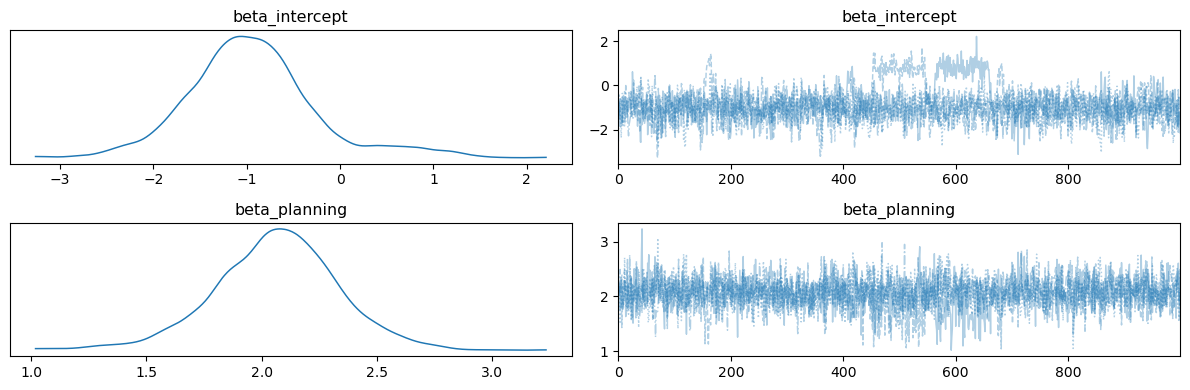

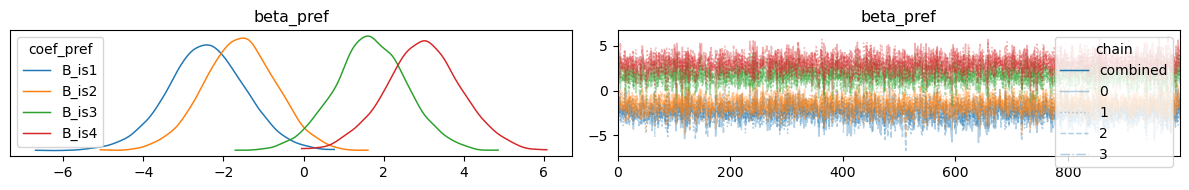

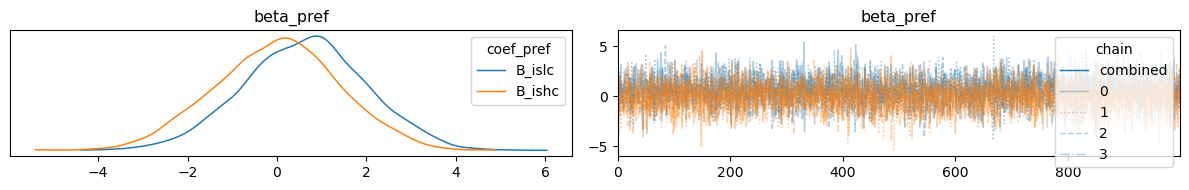

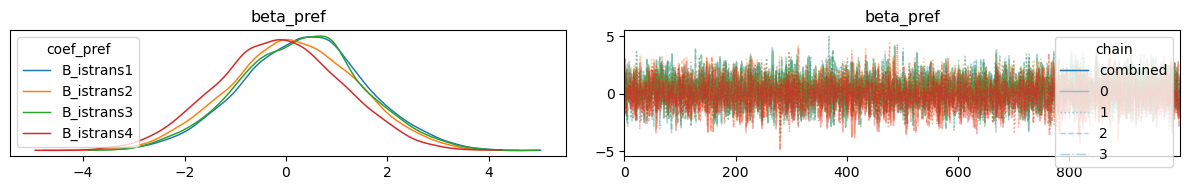

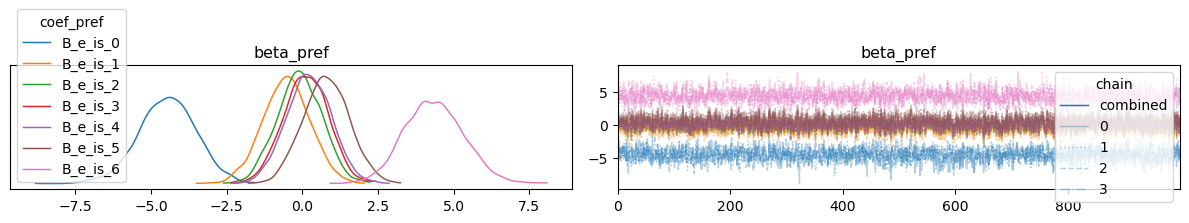

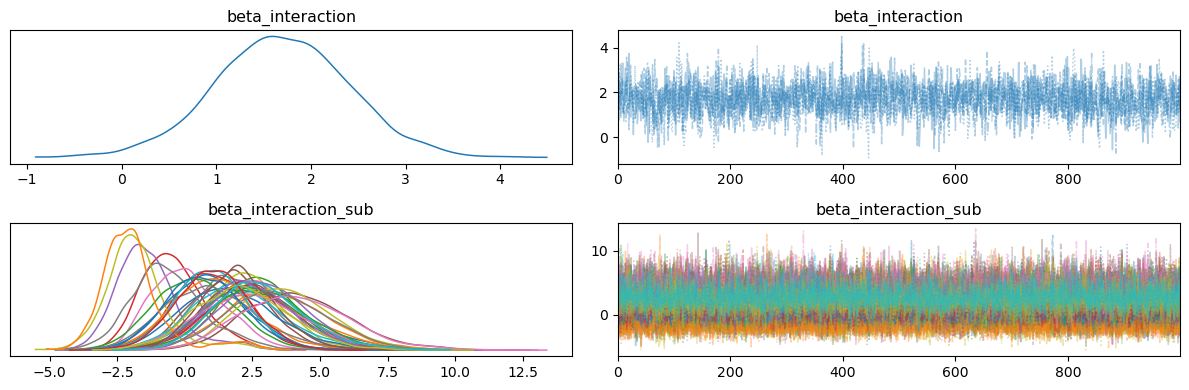

In [3]:
# Add the preference score as a function of hte 

az.plot_trace(traces['model_interaction'], 
              var_names=[
                  "beta_intercept",
                  "beta_planning",
                  ],
              combined=True
            )
plt.tight_layout()

az.plot_trace(traces['model_interaction'], 
              var_names=[
                  "beta_pref",
                  ],
              coords={
                  "coef_pref": ["B_is1", "B_is2", "B_is3", "B_is4"],
                },
              combined=True,
              legend=True
            )
plt.tight_layout()

az.plot_trace(traces['model_interaction'], 
              var_names=[
                  "beta_pref",
                  ],
              coords={
                  "coef_pref": ["B_islc", "B_ishc"],
                },
              combined=True,
              legend=True
            )
plt.tight_layout()

az.plot_trace(traces['model_interaction'], 
              var_names=[
                  "beta_pref",
                  ],
              coords={
                  "coef_pref": ["B_istrans1", "B_istrans2", "B_istrans3", "B_istrans4"]
                },
              combined=True,
              legend=True
            )
plt.tight_layout()

az.plot_trace(traces['model_interaction'], 
              var_names=[
                  "beta_pref",
                  ],
              coords={
                  "coef_pref": ["B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", "B_e_is_4", "B_e_is_5", "B_e_is_6"]
                },
              combined=True,
              legend=True
            )
plt.tight_layout()

az.plot_trace(traces['model_interaction'], 
              var_names=[
                  "beta_interaction",
                  "beta_interaction_sub"
                  ],
              combined=True
            )
plt.tight_layout()

The estimated parameters all seem quite reasonable. We have a positive coefficient for the planning component, indicating that participants behavior do rely on some form of planning and that they scale up the values a bit. In addition, participants show biases that reflect the structure of the task. They tend to reject and accept lowest and higher offer more than they should respectively, as we can see that the coefficient for offer 1 and offer 4 are close to - and +3. Intermediate offers are also symetric around 0, indicating that participants show biases for them as well, though of lower magnitude. This makes a lot of sense given Ott's finding showing that participants are biased away from optimality for extreme offers more than intermediate ones. In terms of costs, participants are not biased all that much, they tend to accept a bit less than they should when cost is high (i.e. overly conservative) and reject a bit more when cost is low (i.e. overly liberal) but that's a very mild effect. Transitions does not seem to play that big a role either, as all the betas are centered on 0. Regarding energy, participants are overly conservatives when they have 0 energy and overly liberal when energy is 6. For intermediate energy levels, participants show incremental bias from being overly conservative to being overly liberal as energy increases. Finally, we observe a significant interaction effect, which we will get back to. 

To better understand the fit, we will plot the posterior probability of accepting the offer (P(a=1)) predicted by our model combining decision values and preferences against the actual behaviour and compare the fit to that of Ott's hybrid model. In addition, we will plot the preferences and entropy for each single state in our task to highlight exactly in which way participants show bias. 

In [4]:
# ===================================================================
# Hybrid model from Ott's (Benchmark)
hybrid_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model'] = hybrid_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv_23, dv_14, is_1, is_2, is_3, is_4, is_full_energy, is_low_energy_LC, is_low_energy_HC, 1|vpn_sigma, 1|vpn_offset, dv_23|vpn_sigma, dv_23|vpn_offset, dv_14|vpn_sigma, dv_14|vpn_offset, is_1|vpn_sigma, is_1|vpn_offset, is_2|vpn_sigma, is_2|vpn_offset, is_3|vpn_sigma, is_3|vpn_offset, is_4|vpn_sigma, is_4|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 110 seconds.


In [5]:
# Extract predicted responses from each model:
data["P(a=1)_dv+Pref"] = np.mean(traces['model_interaction'].posterior["p"], axis=(0, 1))
hybrid_model.predict(traces['hybrid_model'], kind="response_params", inplace=True)
data["P(a=1)_hybrid"] = np.mean(traces['hybrid_model'].posterior["p"], axis=(0, 1))

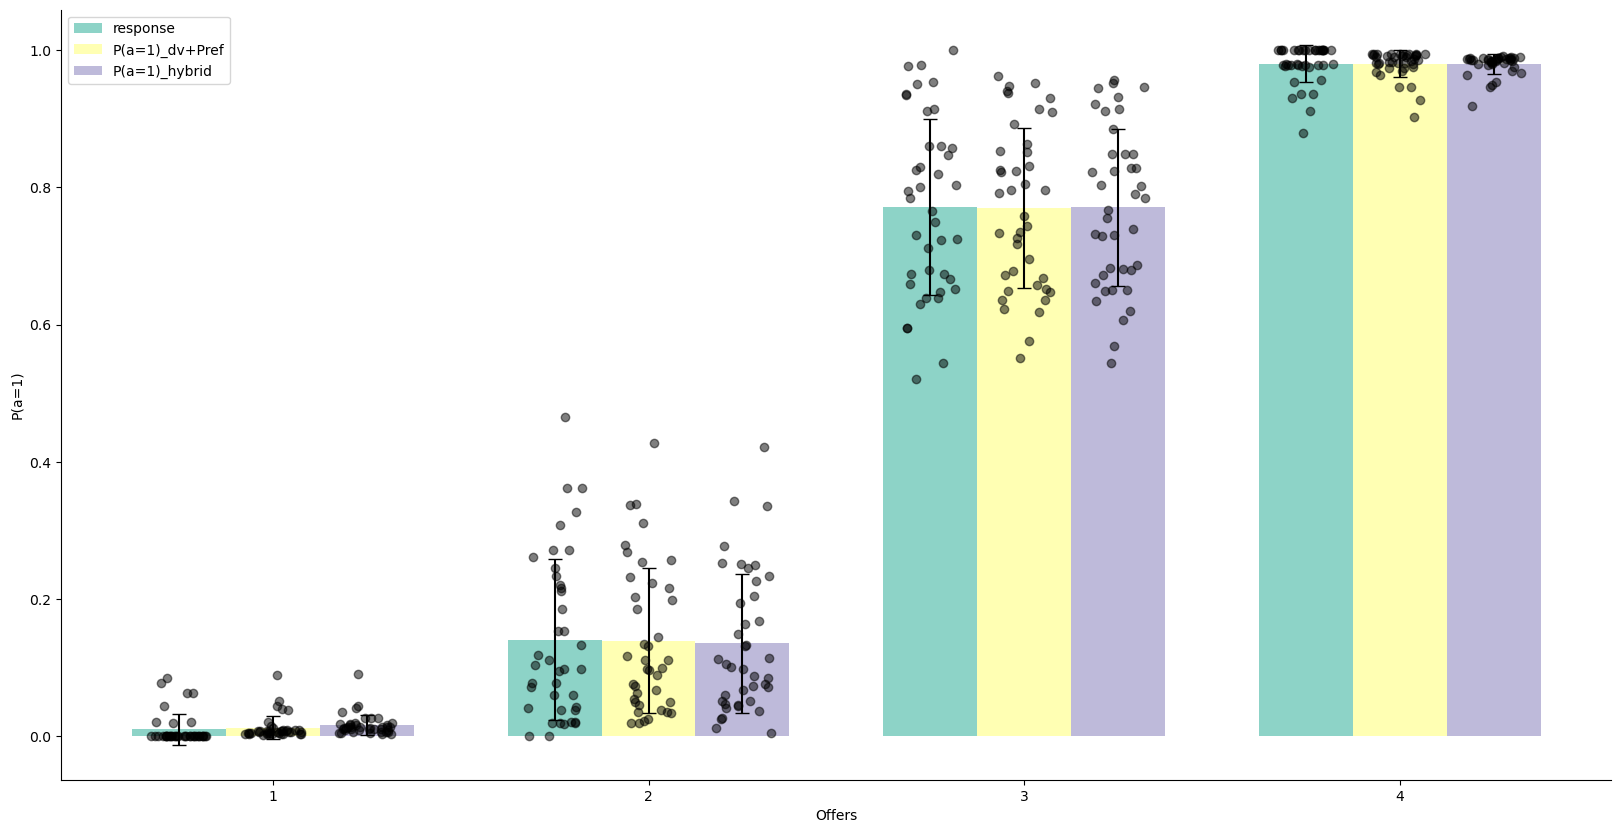

In [6]:
# Remove extreme trials to match Ott#s figure:
data_clean = data[data['is_basic'] == 1]

# Plot the true data against predicted values from each model:
pos = [1, 2, 3, 5, 6, 7, 9, 10, 11, 13, 14, 15]
fig, ax = plt.subplots(figsize=[20, 10])
cmap = matplotlib.colormaps.get_cmap('Set3')
ctr = 0
cols = ["response", "P(a=1)_dv+Pref", "P(a=1)_hybrid"]
for o in [1, 2, 3, 4]:
    for col_i, col in enumerate(cols):
        # Group the data per participants:
        val = data_clean[data_clean['reward'] == o].groupby(['vpn'])[col].mean().reset_index()[col].to_numpy() 
        # Plot average across participants
        if o == 1:
            label = col
        else:
            label = None
        ax.bar(pos[ctr], np.mean(val), width=1, color=cmap(col_i), label=label)
        # Add error bars:
        ax.errorbar(pos[ctr], np.mean(val), yerr=np.std(val), color='k', capsize=5)
        # Plot single participants values:
        ax.scatter(np.random.uniform(0.2, 0.8, len(val)) + pos[ctr]-1/2, val, color='k', alpha=0.5)
        ctr += 1
ax.set_xticks([2, 6, 10, 14])
ax.set_xticklabels([1, 2, 3, 4])
ax.set_xlabel("Offers")
ax.set_ylabel("P(a=1)")
ax.spines[['right', 'top']].set_visible(False)
plt.legend();

We can see that the model combining the preferences and the decision values fits the data better than the hybrid model. To see this in greater details, below is a plot the differences in the observed response frequency and that predicted by each model in each state.

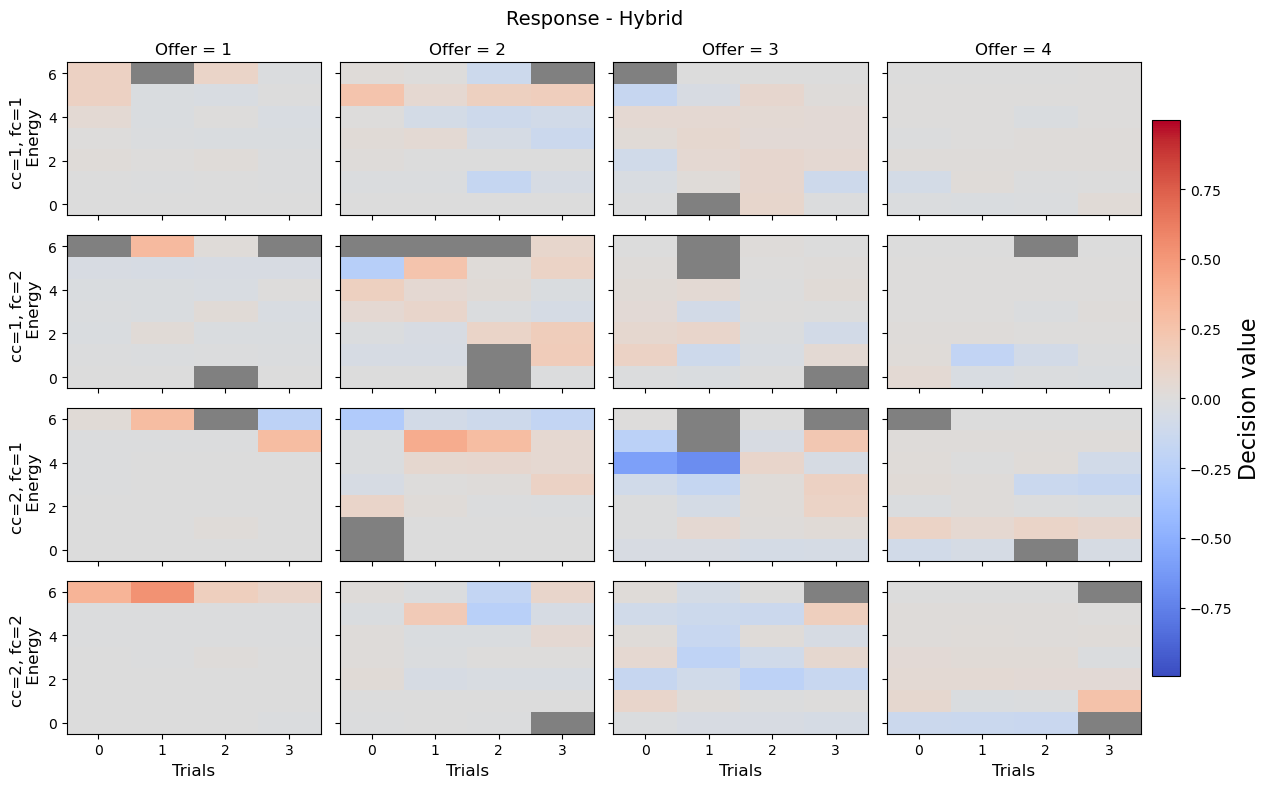

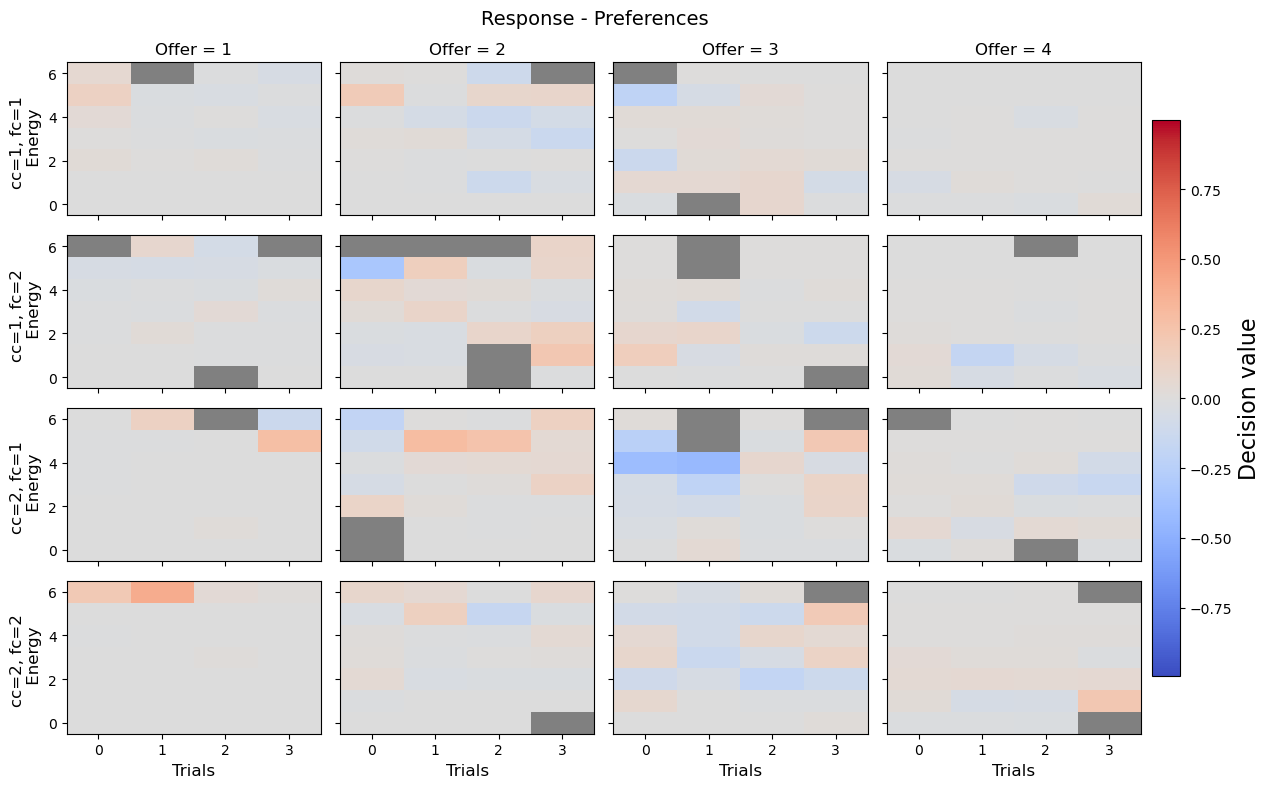

In [7]:
# Posterior decision values:
data["hybrid_response_difference"] = data["response"] - data["P(a=1)_hybrid"]
data["preference_response_differences"] = data["response"] - data["P(a=1)_dv+Pref"]
vmin = np.min([data["hybrid_response_difference"].min(), data["preference_response_differences"].min()])
vmax = np.max([data["hybrid_response_difference"].max(), data["preference_response_differences"].max()])
# Plotting parameters:S
state_cols = ["energy", "reward", "energy_cost", "fc", "trial"]
cmap = plt.get_cmap('coolwarm')
cmap.set_bad("grey")

# =============================================================
# Plot the difference between the true response and the hybrid model predictions:
mean_diff = np.empty(len(task_mdp.states))
for state in task_mdp.states:
    mean_diff[task_mdp.s2i[*state]] = data.loc[(data[state_cols].to_numpy() == state).all(axis=1), 'hybrid_response_difference'].mean()
# Plot:
task_mdp.plot_dv(mean_diff, title=f'Response - Hybrid', tmax=4, cmap=cmap, cmap_midpoint=0, boundary_threshold=None, 
                 vmin=vmin, vmax=vmax);

# =============================================================
# Plot the difference between the true response and the hybrid model predictions:
mean_diff = np.empty(len(task_mdp.states))
for state in task_mdp.states:
    mean_diff[task_mdp.s2i[*state]] = data.loc[(data[state_cols].to_numpy() == state).all(axis=1), 'preference_response_differences'].mean()
# Plot:
task_mdp.plot_dv(mean_diff, title=f'Response - Preferences', tmax=4, cmap=cmap, cmap_midpoint=0, boundary_threshold=None, 
                 vmin=vmin, vmax=vmax);

Overall, the results clearly show that the preference model fits the data best. Specifically...

Now, we will test some additional predictions to further straighten our claim that participants behaviour reflect a trade off between planning and preferences

## Interaction between decision values and preferences
Our results indicate that participants responses are the result of two component: preferences and planning. The planning refers to the decision values associated with an optimal planner (backward induction from RL), while the preferences reflects some propensity of participants to perform specific actions in a given state, regardless of what the optimal action actually is (which might reflect some prior knowledges when facing such problems or whatever other source of biases). We further hypothesized that these two components are not independent. Specifically, we hypothesized that the stronger participants preferences are (i.e. the larger their magnitude regardless of their sign), the less they should rely on the planning component and vice versa. We found evidence for this hypothesis as we observed a significant interaction between the decision values and the entropy of the prefrences, suggesting that participants in fact do tend to downweight the planning component when their preferences are strong.

The fact that planning and preferences both influence the decisions means that mismatch can occur when the sign of the decision values and of the preferences differ:
|             |   Negative  |  Positive |
| ----------- | ----------- | ----------|
| Negative    | Match       | mismatch  |
| Positive    | mismatch    | Match     |

In case of matched signs, we expect participants responses to simply match the sign of both components (accept when positive, reject when negative). In case of mismatch however, which of the two components are participants going to "listen to"? Our prediction is that the weaker the preference, the more the answer should reflect the decision value and vice versa. We can therefore have all these different outcomes in case of mismatchs:
1. Decision value > 0, Preference < 0, Response = Accept
2. Decision value < 0, Preference > 0, Response = Reject
3. Decision value > 0, Preference < 0, Response = Reject
4. Decision value < 0, Preference > 0, Response = Accept

Option 1. and 2. are cases where participants responses reflect the decision values over the preferences. We predict that these points should cluster in areas of the right bottom quadrant of the plot (positive decision values and negative preference scores) and top left quadrant (negative decision values and positive preference scores), in both cases towards the extremities of the x axis (large decision values) but close to the center of the y axis (preference close to 0). In contrast, option 3. and 4. are cases where participants responses reflct the preference score over the decision values, which we predict should occur when preferences are large and decision values are small. We therefore predict that these points should cluster on the top left and bottom right quadrant (quadrant where x and y signs are opposed, i.e. mismatchs), but instead of clustering close to the center of the y axis and on the extremities of the x axis, they should cluster on the center of the x axis but towards the extremities of the y axis (decision values close to 0 and large preference score). 

We will plot cases 1, 2, 3 and 4 in different colors, while the non-mismatch cases will be plotted in the same color:

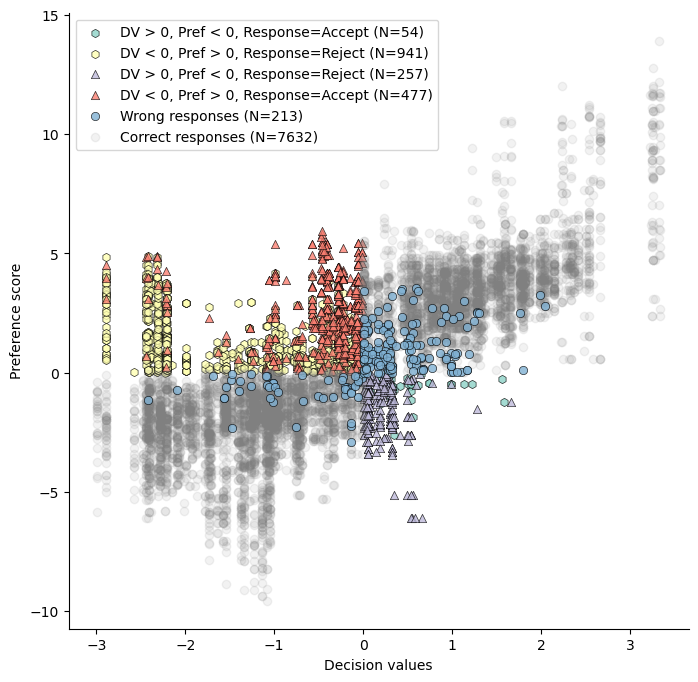

In [8]:
fig, ax = plt.subplots(figsize=[8, 8], sharex=True, sharey=True)
cmap = matplotlib.colormaps.get_cmap('Set3')
# Add the preferences as an additional column to the data:
data['preference_score'] = np.mean(traces['model_interaction'].posterior["preference"], axis=(0, 1))
data['response_centered'] = data['response'] - 0.5

# mismatch 1:
mismatch_1 = data[(data['dv'] > 0) & 
                  (data['preference_score'] < 0) & 
                  (data['response_centered'] > 0)]
# mismatch 2:
mismatch_2 = data[(data['dv'] < 0) & 
                  (data['preference_score'] > 0) & 
                  (data['response_centered'] < 0)]
# mismatch 3:
mismatch_3 = data[(data['dv'] > 0) & 
                  (data['preference_score'] < 0) & 
                  (data['response_centered'] < 0)]
# mismatch 4:
mismatch_4 = data[(data['dv'] < 0) & 
                  (data['preference_score'] > 0) & 
                  (data['response_centered'] > 0)]
# Wrong responses in the absence of mismatchs:
wrong_responses = data[(np.sign(data['dv']) == np.sign(data['preference_score'])) &
                       (np.sign(data['dv']) != np.sign(data['response_centered']))]
# Correct responses in the absence of mismatchs:
correct_responses = data[(np.sign(data['dv']) == np.sign(data['preference_score'])) &
                         (np.sign(data['dv']) == np.sign(data['response_centered']))]

# Plot each mismatch
ax.scatter(mismatch_1['dv'], mismatch_1['preference_score'], color=cmap(0), edgecolors='black', linewidths=0.5, label=f'DV > 0, Pref < 0, Response=Accept (N={mismatch_1.shape[0]})', marker='h', alpha=0.8)
ax.scatter(mismatch_2['dv'], mismatch_2['preference_score'], color=cmap(1), edgecolors='black', linewidths=0.5, label=f'DV < 0, Pref > 0, Response=Reject (N={mismatch_2.shape[0]})', marker='h', alpha=0.8)
ax.scatter(mismatch_3['dv'], mismatch_3['preference_score'], color=cmap(2), edgecolors='black', linewidths=0.5, label=f'DV > 0, Pref < 0, Response=Reject (N={mismatch_3.shape[0]})', marker='^', alpha=0.8)
ax.scatter(mismatch_4['dv'], mismatch_4['preference_score'], color=cmap(3), edgecolors='black', linewidths=0.5, label=f'DV < 0, Pref > 0, Response=Accept (N={mismatch_4.shape[0]})', marker='^', alpha=0.8)
ax.scatter(wrong_responses['dv'], wrong_responses['preference_score'], color=cmap(4), edgecolors='black', linewidths=0.5, label=f'Wrong responses (N={wrong_responses.shape[0]})', marker='o', alpha=0.8, zorder=1000)
ax.scatter(correct_responses['dv'], correct_responses['preference_score'], color="grey", label=f'Correct responses (N={correct_responses.shape[0]})', marker='o', alpha=0.1)
# Decoration:
ax.set_xlabel("Decision values")
ax.set_ylabel("Preference score")
ax.spines[['right', 'top']].set_visible(False)
plt.legend();

These data match what we predicted. The triangle markers represent mismatch where participants decision reflects preferences, hexagons represent mismatches where participants response reflect the decision values. Grey circles represent trials where preference and decision are matched and participants respond accordingly, blue circles represent trials where preference and responses are matched but participants respond otherwise. 

First, we can see that for the majority of trials, preferences and decision values are matched in their signs (grey and blue circles, 7600+212=7812 out of 9574 trials total), indicating that the two are quite correlated with each other. In other words, participants preference aren't to far off compared to optimal behaviour. In case of matched trials (trials where preference and decision values are matched), there are still quite a few cases where participants respond 'wrongly'. Notably, these dots cluster towards the center of the plot for the most part. This makes sense, as when both preference and decision values are close to 0, it is less clear which response is the most appropriate.

Regarding mismatch trials, we observe that the trianlges mostly cluster close to the center of the x axis, that is in states for which the decision value is close to 0. In contrast, the hexagons (especially the yellow ones) cluster towards the extremities of the x axis, where the decision values are larger. Notably, a lot of mismatchs where both the decision values and the preferences scores are low (towards the center left of the figure) appear to be in favour of the decision values. In addition, there are way fewer data points on the bottom right corner, indicating that there are few instances in which participants prefer to reject the offer when the optimal plan suggests accepting. This indicates that participants preferences are overall liberal: they tend to accept offers a bit more often than they should. 

We can look at the same results seprately for each offers:

/tmp/ipykernel_7205/2609151869.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


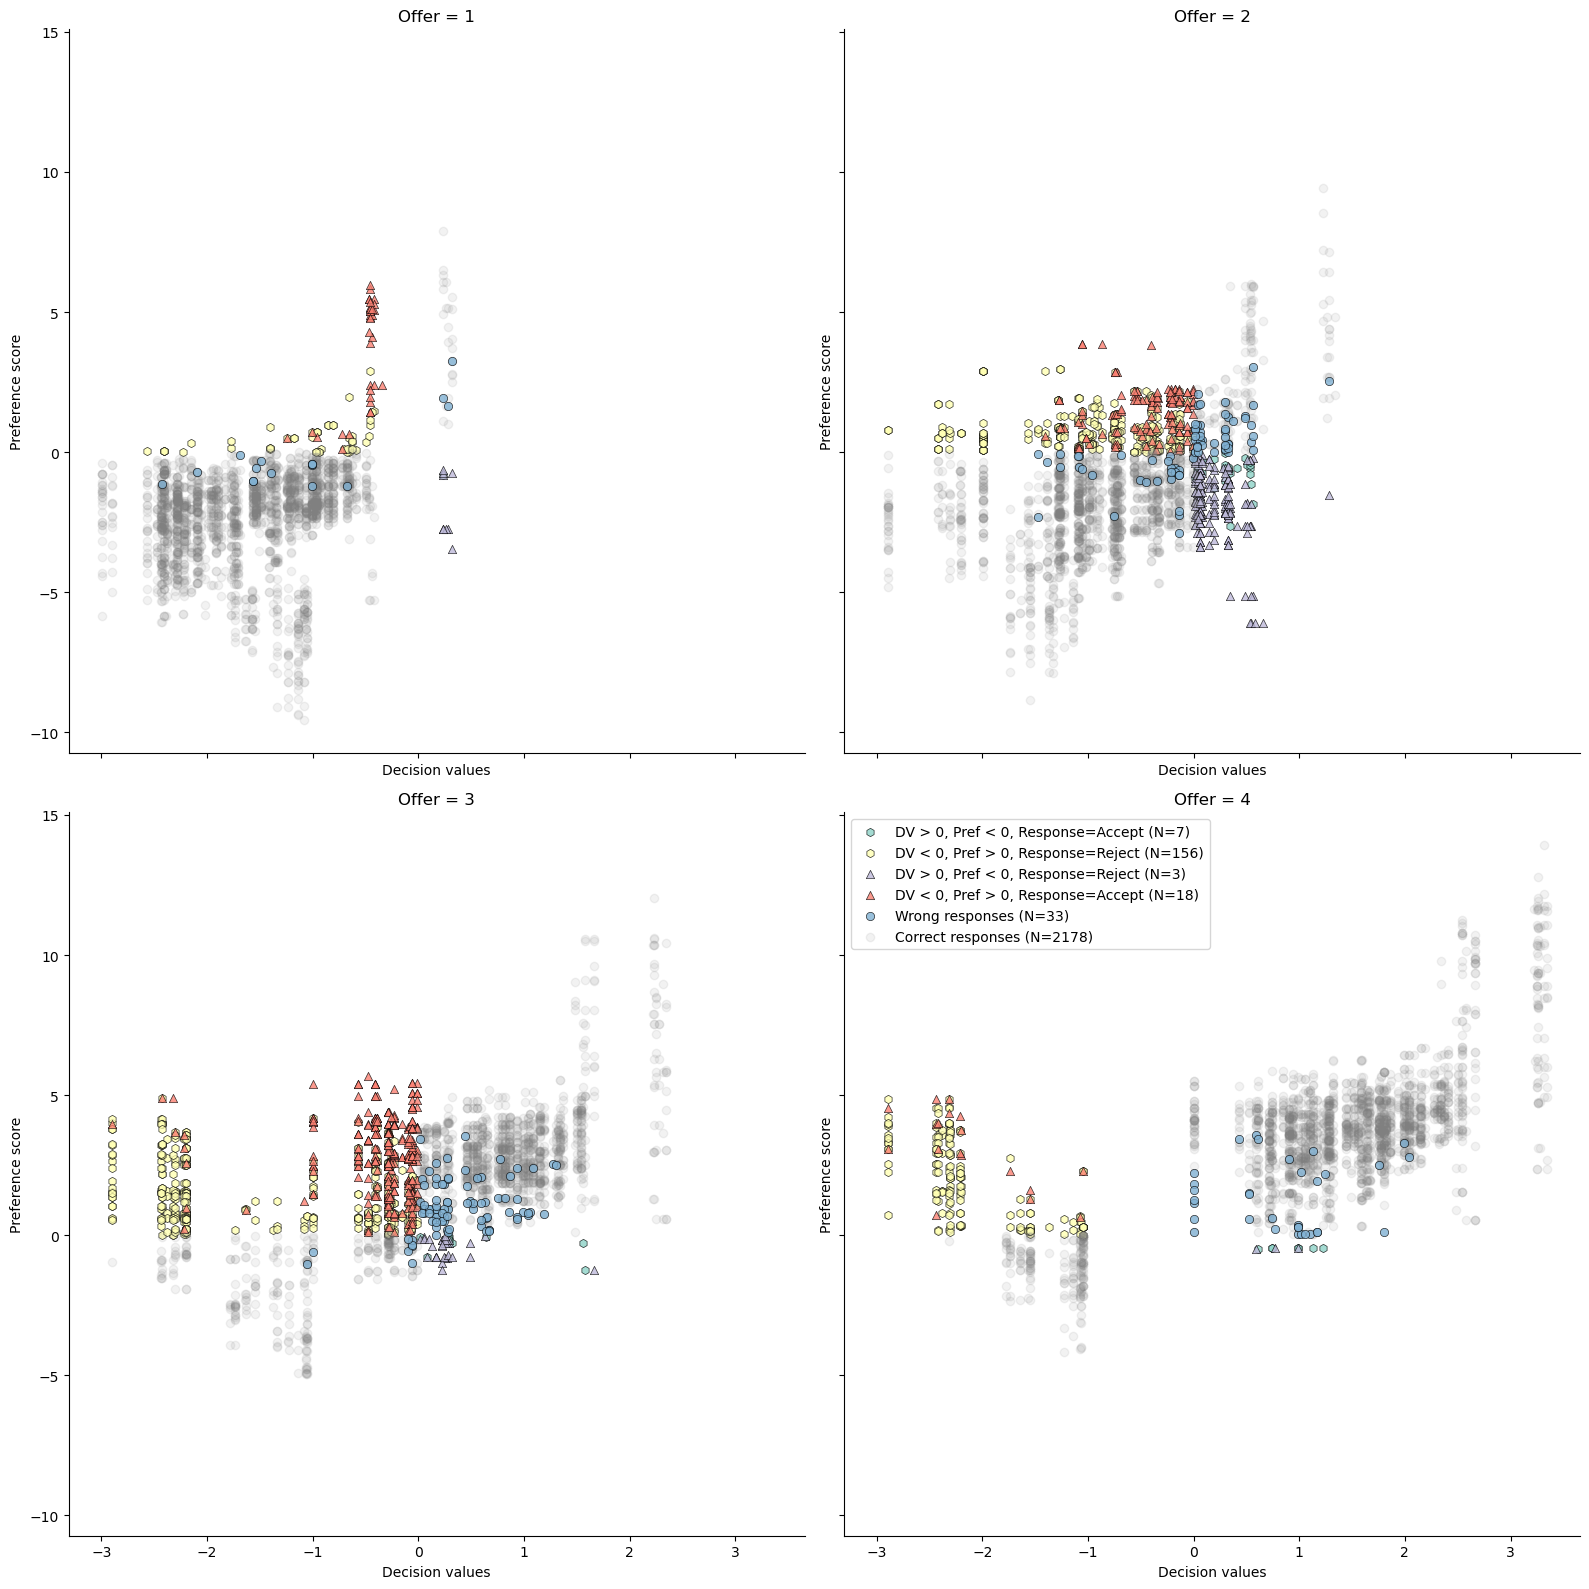

In [9]:
fig, ax = plt.subplots(2, 2, figsize=[16, 16], sharex=True, sharey=True)
ax = ax.flatten()

for i, o in enumerate([1, 2, 3, 4]):

    # Add the preferences as an additional column to the data:
    data_offer = data[data['reward'] == o]

    # mismatch 1:
    mismatch_1 = data_offer[(data_offer['dv'] > 0) & 
                    (data_offer['preference_score'] < 0) & 
                    (data_offer['response_centered'] > 0)]
    # mismatch 2:
    mismatch_2 = data_offer[(data_offer['dv'] < 0) & 
                    (data_offer['preference_score'] > 0) & 
                    (data_offer['response_centered'] < 0)]
    # mismatch 3:
    mismatch_3 = data_offer[(data_offer['dv'] > 0) & 
                    (data_offer['preference_score'] < 0) & 
                    (data_offer['response_centered'] < 0)]
    # mismatch 4:
    mismatch_4 = data_offer[(data_offer['dv'] < 0) & 
                    (data_offer['preference_score'] > 0) & 
                    (data_offer['response_centered'] > 0)]
    # Wrong responses in the absence of mismatchs:
    wrong_responses = data_offer[(np.sign(data_offer['dv']) == np.sign(data_offer['preference_score'])) &
                        (np.sign(data_offer['dv']) != np.sign(data_offer['response_centered']))]
    # Correct responses in the absence of mismatchs:
    correct_responses = data_offer[(np.sign(data_offer['dv']) == np.sign(data_offer['preference_score'])) &
                            (np.sign(data_offer['dv']) == np.sign(data_offer['response_centered']))]

    # Plot each mismatch
    ax[i].scatter(mismatch_1['dv'], mismatch_1['preference_score'], color=cmap(0), edgecolors='black', linewidths=0.5, label=f'DV > 0, Pref < 0, Response=Accept (N={mismatch_1.shape[0]})', marker='h', alpha=0.8)
    ax[i].scatter(mismatch_2['dv'], mismatch_2['preference_score'], color=cmap(1), edgecolors='black', linewidths=0.5, label=f'DV < 0, Pref > 0, Response=Reject (N={mismatch_2.shape[0]})', marker='h', alpha=0.8)
    ax[i].scatter(mismatch_3['dv'], mismatch_3['preference_score'], color=cmap(2), edgecolors='black', linewidths=0.5, label=f'DV > 0, Pref < 0, Response=Reject (N={mismatch_3.shape[0]})', marker='^', alpha=0.8)
    ax[i].scatter(mismatch_4['dv'], mismatch_4['preference_score'], color=cmap(3), edgecolors='black', linewidths=0.5, label=f'DV < 0, Pref > 0, Response=Accept (N={mismatch_4.shape[0]})', marker='^', alpha=0.8)
    ax[i].scatter(wrong_responses['dv'], wrong_responses['preference_score'], color=cmap(4), edgecolors='black', linewidths=0.5, label=f'Wrong responses (N={wrong_responses.shape[0]})', marker='o', alpha=0.8, zorder=1000)
    ax[i].scatter(correct_responses['dv'], correct_responses['preference_score'], color="grey", label=f'Correct responses (N={correct_responses.shape[0]})', marker='o', alpha=0.1)
    # Decoration:
    ax[i].set_xlabel("Decision values")
    ax[i].set_ylabel("Preference score")
    ax[i].set_title(f"Offer = {o}")
    ax[i].spines[['right', 'top']].set_visible(False)
    plt.legend();
plt.tight_layout()

# Reaction times
In Ott's paper, they have observed that participants reaction time is correlated with what they've called 'conflict', which is the negative of the absolute value of the decision values. The lower the conflict value, the larger the difference in value between accept and reject. This makes sense, the larger the difference in value, the more 'obvious' the optimal decision, hence faster RT. However, they've also observed an interactionm between conflict and offers, such that the effect of conflict on RT is more pronounced for intermediate (2 and 3) than for extreme offers (1 and 4). In other words, participants reaction time doesn't grow as rapidly as a function of conflict for extreme offer as for intermediate offers, which indicates that participants invest more time and effort in forward planning in intermediate offers compared to extreme offers when conflict is high. 

Their interpretation is that participants represent tasks in separate contexts, each requiring different levels of planning. That is, intermediate offer form a context associated with high planning requirements. Extreme offers on the other hand require less planning. An open question is why do participants infer that intermediate offer require less planning? One possibility based on our current findings is that participants investment in forward planning depends on the strength of their preferences. When participants have strong preferences, we would expect them to rely on those more heavily and less on planning, which should result in faster RT. The observed interaction between conflict and intermediate trials might be explained by overall weaker preferences in intermediate offers making them rely more heavily on planning as conflict increases in those conditions.

A refined alternative is that the RT reflects an interaction between preferences and decision values. A positive interaction between decision values and preferences entropy would indicate that when preferences grow weaker, the slope of RT as a function of decision values increase. That is, participants might dedicate more cognitive resources when conflict increase and preferences grow weaker. This might also account for Ott's findings of increased RT slope in intermediate trials if preferences generally weaker across intermediate trials. 

To explore both these options, we will first plot the RT as a function of conflict and preferences entropy to visualize the effects before fitting a model with the effect of entropy alone and the interaction between conflict and entropy:

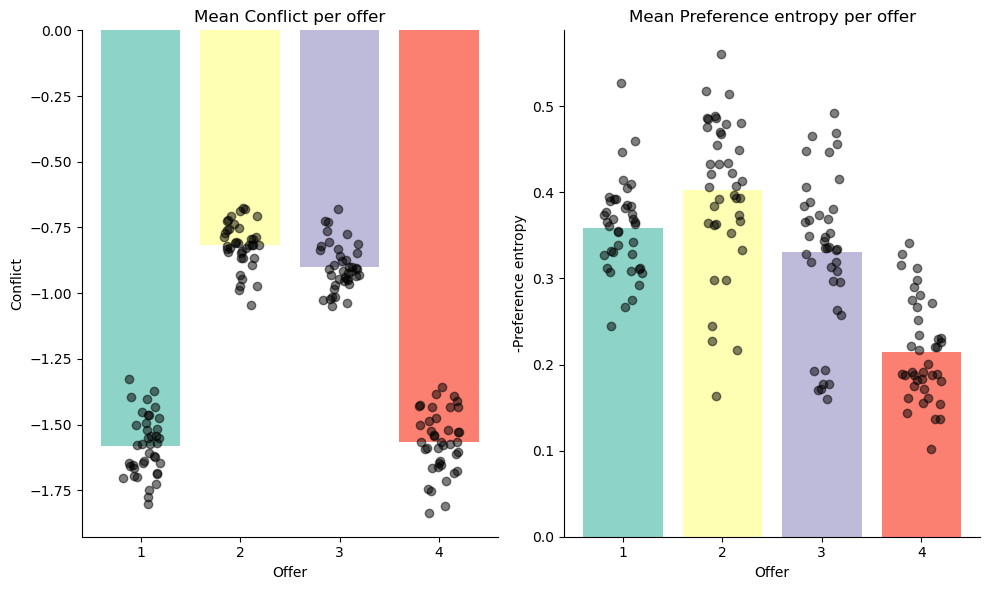

In [10]:
fig, ax = plt.subplots(1, 2, figsize=[10, 6], sharex=True)
pos = [1, 2, 3, 4]
data['conflict'] = -np.abs(data['dv'])
data['entropy'] = np.mean(traces['model_interaction'].posterior["entropy"], axis=(0, 1))

for i, o in enumerate([1, 2, 3, 4]):
    # Extract offer data:
    data_offer = data[data['reward'] == o]
    # Compute average in each subject:
    val = data_offer.groupby(['vpn']).mean().reset_index()['conflict'].to_numpy()
    # Plot mean ratio:
    ax[0].scatter(pos[i] + np.random.uniform(-0.2, 0.2, len(val)), val, color='k', alpha=0.5, zorder=1000)
    ax[0].bar(pos[i], np.mean(val), color=cmap(i))
ax[0].set_xticks(pos)
ax[0].set_xticklabels([1, 2, 3, 4])
ax[0].set_ylabel("Conflict")
ax[0].set_xlabel("Offer")
ax[0].set_title("Mean Conflict per offer")
ax[0].spines[['right', 'top']].set_visible(False)

for i, o in enumerate([1, 2, 3, 4]):
    # Extract offer data:
    data_offer = data[data['reward'] == o]
    # Compute average in each subject:
    val = data_offer.groupby(['vpn']).mean().reset_index()['entropy'].to_numpy()
    # Plot mean ratio:
    ax[1].scatter(pos[i] + np.random.uniform(-0.2, 0.2, len(val)), val, color='k', alpha=0.5, zorder=1000)
    ax[1].bar(pos[i], np.mean(val), color=cmap(i))
ax[1].set_xticks(pos)
ax[1].set_xticklabels([1, 2, 3, 4])
ax[1].set_ylabel("-Preference entropy")
ax[1].set_xlabel("Offer")
ax[1].set_title("Mean Preference entropy per offer")
ax[1].spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.show()

From this figure, it is clear that intermediate offer have on average higher conflict. It is however not clear that participants have stronger preferences for extreme than intermediate values. This could however be obscured by averaging across trials. To investigate this effect more closely, we can plot the RT as a function of conflict separately for intermediate and extreme offers, color coded by preferences:


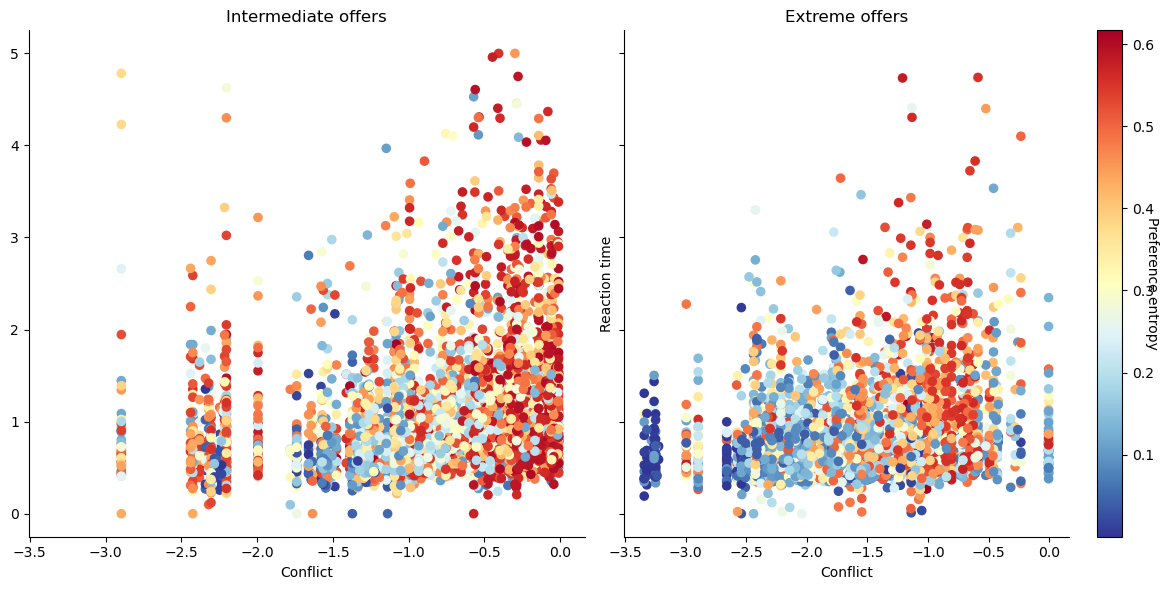

In [11]:
data_intermediate = data[(data['is_2'] == 1) | (data['is_3'] == 1)]
data_extreme = data[(data['is_2'] == 0) & (data['is_3'] == 0)]
cmap = plt.get_cmap('RdYlBu_r')

fig, ax = plt.subplots(1, 2, figsize=[12, 6], sharex=True, sharey=True)
ax[0].scatter(data_intermediate['conflict'], data_intermediate['reaction_time'], c=data_intermediate['entropy'], vmin=data['entropy'].min(), vmax=data['entropy'].max(), s=35, cmap=cmap)
ax[0].set_title("Intermediate offers")
ax[0].set_xlabel("Conflict")
ax[0].spines[['right', 'top']].set_visible(False)
sc = ax[1].scatter(data_extreme['conflict'], data_extreme['reaction_time'], c=data_extreme['entropy'], vmin=data_extreme['entropy'].min(), vmax=data_extreme['entropy'].max() , s=35, cmap=cmap)
cbar = plt.colorbar(sc, ax=ax[1]);
cbar.set_label('Preference entropy', rotation=270)
ax[1].set_title("Extreme offers")
ax[1].set_xlabel("Conflict")
ax[1].set_ylabel("Reaction time") 
ax[1].spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.show();

From these graphs, it appears that indeed, the slope of reaction time as a function of conflict is more pronouned for the intermediate compared to the extreme offers, in line with Ott's results. However, we can also see that in intermediate offers, preference seem to be quite weak (high entropy = preferences closer to 0) when conflict is close to 0 (and to some extent all throughout decision values). In comparison, in extreme offers, preferences seem to be weakest for intermediate conflict values (from -2.0 to 0.5). In extreme offers, the lowest conflict (around -3.5) are associated with strong preferences. 

We will now fit models on RT to investigate these various effects:

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, conflict, intermediate, conflict:intermediate, 1|vpn_sigma, 1|vpn_offset, conflict|vpn_sigma, conflict|vpn_offset, intermediate|vpn_sigma, intermediate|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 41 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, entropy, 1|vpn_sigma, 1|vpn_offset, entropy|vpn_sigma, entropy|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, conflict, entropy, conflict:entropy, 1|vpn_sigma, 1|vpn_offset, conflict|vpn_sigma, conflict|vpn_offset, entropy|vpn_sigma, entropy|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 51 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
preference_conflict_rt_model,0,-5988.202930,140.170444,0.000000,0.793360,414.424519,0.000000,True,log
ott_rt_mdl,1,-6123.905673,136.757477,135.702743,0.143559,406.664923,26.946359,True,log
preference_rt_model,2,-6305.645908,105.438340,317.442978,0.063081,401.252382,34.458902,True,log


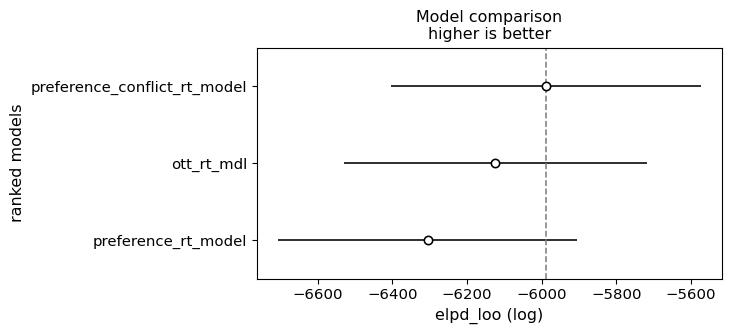

In [12]:
data['logRT'] = np.log(data['reaction_time'])

# Repeat Ott's RT model:
data['conflict'] = -np.abs(data['dv'])
data['intermediate'] = data['is_2'] + data['is_3']
data['entropy'] = np.mean(traces['model_interaction'].posterior["entropy"], axis=(0, 1))

traces_RT = {}
# Fit Ott's RT model:
ott_rt_mdl = bmb.Model(
    "logRT ~ conflict + intermediate + conflict:intermediate +"
    "(conflict + intermediate|vpn)", 
    data
    )
traces_RT['ott_rt_mdl'] = ott_rt_mdl.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# Fit an alternative model based with only entropy as a regressor:
pref_rt_mdl = bmb.Model(
    "logRT ~ entropy +"
    "(entropy|vpn)", 
    data
    )
traces_RT['preference_rt_model'] = pref_rt_mdl.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# Fit an alternative model based on preferences scores:
pref_conflict_rt_model = bmb.Model(
    "logRT ~ conflict + entropy + conflict:entropy +"
    "(conflict + entropy|vpn)", 
    data
    )
traces_RT['preference_conflict_rt_model'] = pref_conflict_rt_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# Compare the models:
model_comparison = az.compare(traces_RT)
az.plot_compare(model_comparison);
model_comparison

In line with our prediction, the model with interaction between preference entropy and conflict performs the best. Let's vizualize the parameters fits:

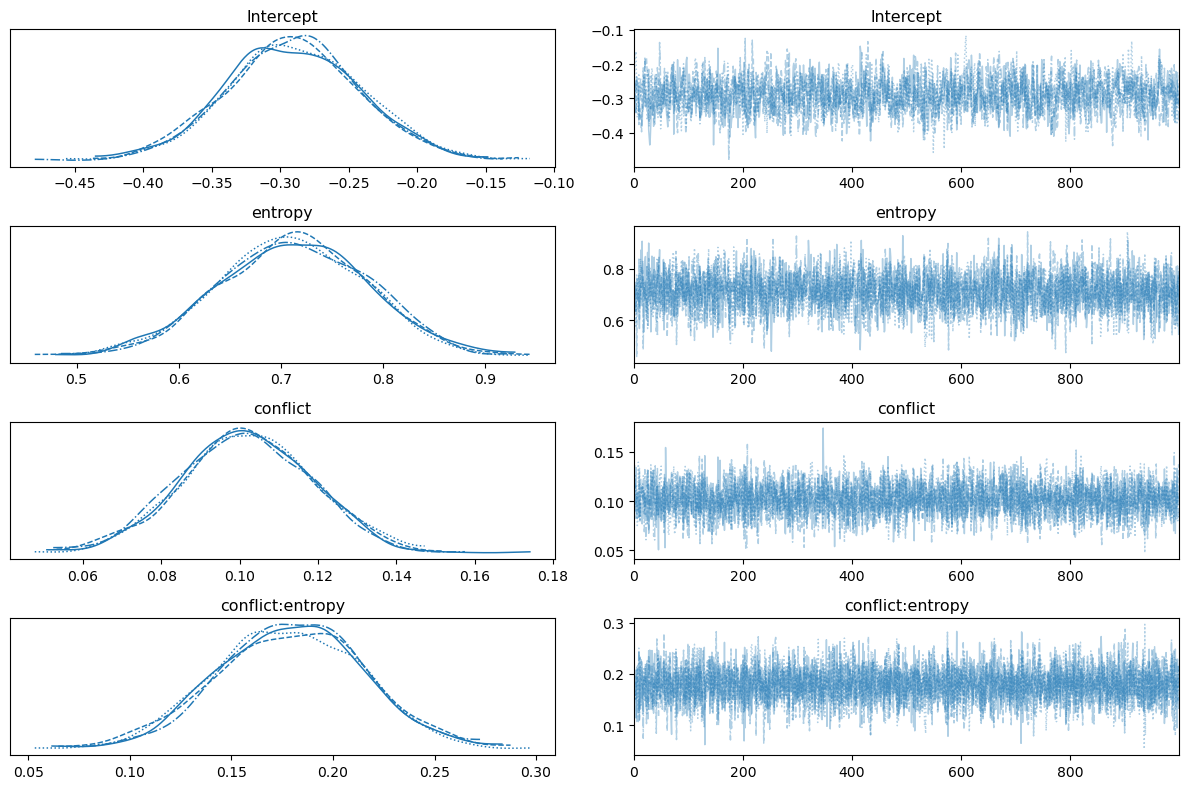

In [13]:
az.plot_trace(traces_RT['preference_conflict_rt_model'],
              var_names=[
                  "Intercept",
                  "entropy",
                  "conflict",
                  "conflict:entropy"
                  ]
                )
plt.tight_layout();

The interaction between entropy and conflict is positive, which indicates that as preferences grow weaker, the slope of RT as a function of decision values increase. To vizualize it, we will simulate some data:

Default computed for unspecified variable: vpn


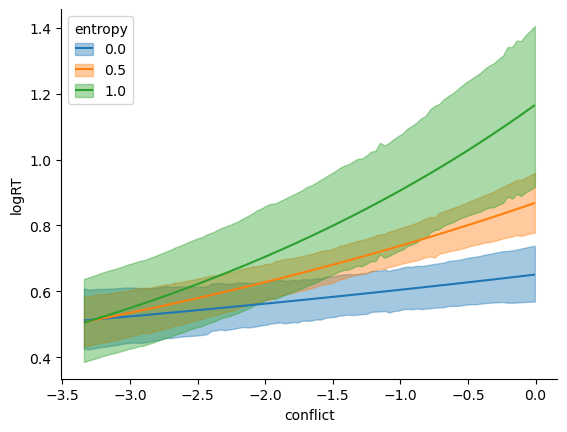

In [14]:
fig = bmb.interpret.plot_predictions(
    pref_conflict_rt_model,
    traces_RT['preference_conflict_rt_model'],
    conditional={
        "conflict": np.linspace(data['conflict'].min(), data['conflict'].max(), 100),
        "entropy": [0, 0.5, 1]
    },
    transforms={"logRT": np.exp}
);
fig[1][0].spines[['right', 'top']].set_visible(False)

These results indicate that the stronger the preference (the closest the entropy is to 0), the less participants RT depends on the conflict (the blue line is much flatter than the green one). These results clearly match our predictions that the extent to which participants engage in planning depends on both the decision value and the strength of their preferences. When conflict is low, participants are able to respond quickly regardless of their preferences, most likely due to some approximation of the value function indicating that the decision is very simple (there is a clear winning action). However, as conflict increases, participants will engage in extensive planning only if their preference is quite weak. Otherwise, they rely only on their preference. 